# RetainIQ — Tenure Cohort Analysis: Retention Curve & Churn Trend

Further Phase 1 EDA deep-dive, alongside `02_churn_patterns.ipynb`. All analysis logic lives in `src/data/cohorts.py` and `src/data/load_data.py` — this notebook only calls into them and renders the results.

Bins customers into the four requested tenure cohorts (0-12, 12-24, 24-48, 48-72 months), reports churn/retention rate per cohort, and charts an **empirical retention curve** (`% of customers with tenure >= m`). That curve is *not* a censoring-corrected Kaplan-Meier survival estimate — see the caveat in Section 3 and `.claude/specs/03-cohort-analysis.md` for the methodology decision behind that simplification.

In [1]:
import sys
from pathlib import Path

# Allow `import src...` when the notebook is run from notebooks/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
from IPython.display import Image, display

from src.data.config import FIGURES_DIR
from src.data.load_data import load_clean_data
from src.data.cohorts import (
    TENURE_COHORT_LABELS,
    assign_tenure_cohort,
    cohort_summary,
    empirical_retention_curve,
    generate_cohort_figures,
)

pd.set_option("display.max_columns", None)
df = load_clean_data()
df.shape

(7043, 20)

Regenerate the cohort charts before rendering any of them below, so the images this notebook displays are always current for whatever `df` was just loaded.

In [2]:
paths = generate_cohort_figures(df)
print(f"Saved {len(paths)} figures to reports/figures/")

Saved 2 figures to reports/figures/


## 1. Cohort assignment

In [3]:
cohort = assign_tenure_cohort(df)
cohort.value_counts().reindex(TENURE_COHORT_LABELS)

tenure
0-12     2186
12-24    1024
24-48    1594
48-72    2239
Name: count, dtype: int64

All 7,043 customers fall into exactly one of the four requested tenure bands (0-12, 12-24, 24-48, 48-72 months) — `tenure` never exceeds 72 in this dataset, so the fixed bin edges partition the data with no gaps and no unassigned rows.

## 2. Churn & retention rate by cohort

In [4]:
display(cohort_summary(df))

,cohort,customers,churn_rate,retention_rate
0,0-12,2186,47.44,52.56
1,12-24,1024,28.71,71.29
2,24-48,1594,20.39,79.61
3,48-72,2239,9.51,90.49


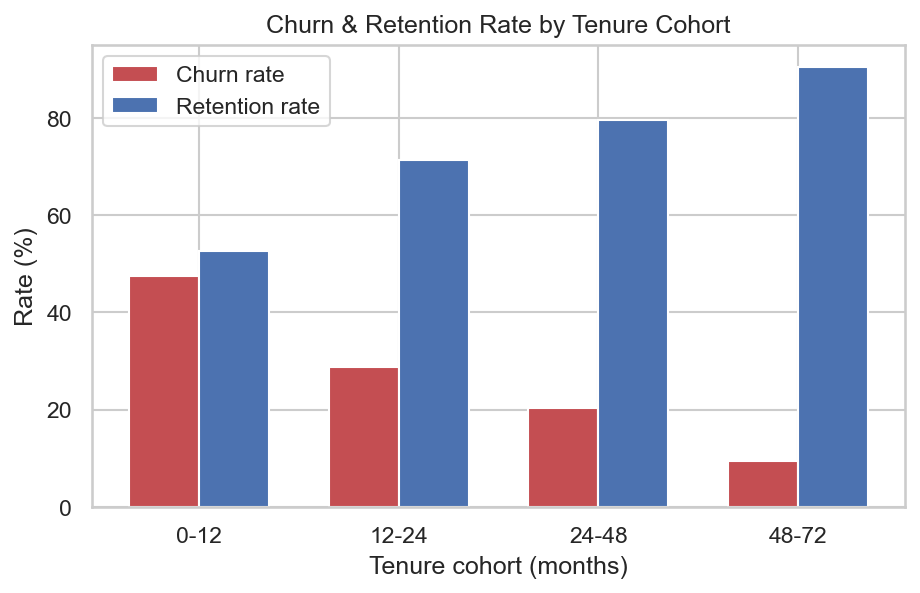

In [5]:
display(Image(str(FIGURES_DIR / "cohort_churn_trend.png")))

Churn risk falls steeply and monotonically with tenure: **47.44%** in the first year down to **9.51%** by year 4+ — a ~5x gap between the newest and longest-tenured cohorts. This is the concrete, quantified version of CLAUDE.md §6's "churn concentrated in first 12 months" signal, and it argues directly for front-loading retention investment (onboarding, first-year offers) rather than spreading it evenly across the customer base.

## 3. Empirical retention curve

**Caveat:** this dataset is a single cross-sectional snapshot — each customer has one `tenure` value and one `Churn` flag, not repeated observations over time. The curve below plots `% of customers with tenure >= m` (1 minus the empirical CDF of tenure) at each month `m`. It is **not** a censoring-corrected Kaplan-Meier survival estimate: it mixes customers who are still active with customers who already churned, and it does not distinguish "this customer left at month m" from "this customer simply hasn't been observed that long yet." That's why the curve drops to ~5% by month 72 — few customers in this snapshot have been on the books that long, not because 95% of customers churn by then. Read it as a description of how long today's customer base has stuck around, not as a forecast of any individual customer's survival odds.

In [6]:
curve = empirical_retention_curve(df)
display(curve[curve["month"].isin([0, 12, 24, 36, 48, 60, 72])])

,month,retention_pct,n_at_risk
0,0,100.000000,7043
12,12,70.623314,4974
24,24,55.757490,3927
36,36,43.319608,3051
48,48,32.699134,2303
60,60,21.056368,1483
72,72,5.139855,362


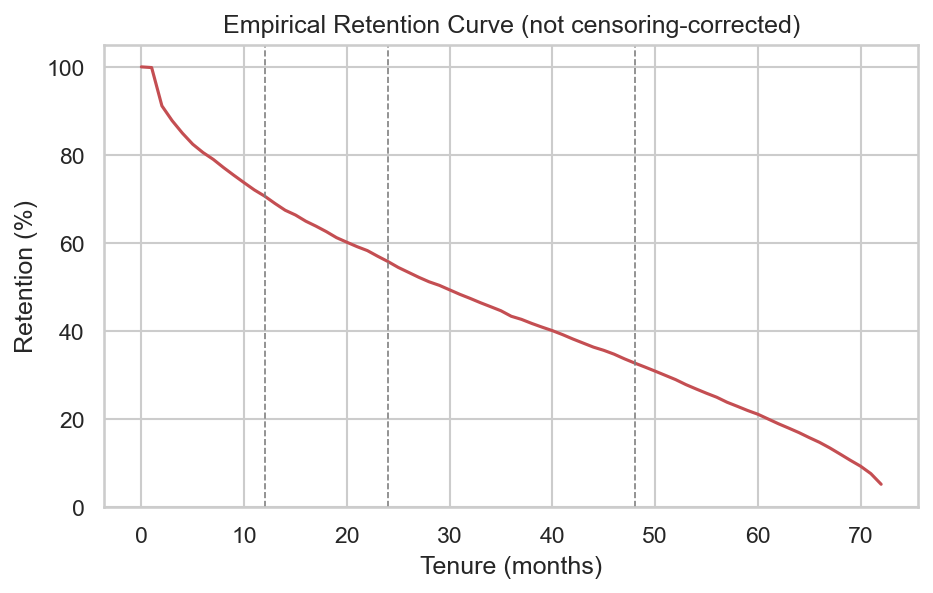

In [7]:
display(Image(str(FIGURES_DIR / "retention_curve.png")))

## Key findings

- **Tenure cohorts partition cleanly**: 2,186 customers in 0-12 months, 1,024 in 12-24, 1,594 in 24-48, 2,239 in 48-72 — all 7,043 customers assigned, no gaps.
- **Churn rate falls monotonically with tenure**: 47.44% -> 28.71% -> 20.39% -> 9.51% across the four bands, a ~5x drop from newest to longest-tenured customers.
- **The empirical retention curve is descriptive, not predictive**: it is 1 minus the ECDF of `tenure`, not a censoring-corrected survival estimate. A true Kaplan-Meier curve (via `lifelines`) was considered and explicitly deferred, since it falls outside CLAUDE.md §3's approved tech stack.
- **Retention-focused action**: the steep early drop-off says onboarding and first-year retention offers have the highest leverage — a customer who reaches the 48-72 month cohort is already far less likely to churn.